# Notebook 08 — Árboles de decisión para regresión

En este notebook estudiaremos cómo un árbol de regresión construye predicciones mediante particiones sucesivas del espacio de variables.

## Objetivos

Al finalizar el notebook deberías ser capaz de:

- explicar cómo un árbol divide los datos;
- interpretar nodos, ramas y hojas;
- ajustar un `DecisionTreeRegressor`;
- visualizar las predicciones constantes por región;
- analizar el efecto de la profundidad;
- identificar overfitting en árboles;
- controlar la complejidad mediante hiperparámetros;
- interpretar la importancia de variables;
- utilizar poda por costo-complejidad;
- reconocer las limitaciones de extrapolación.

Usaremos datos sintéticos para visualizar con claridad las reglas aprendidas.

## 1. Importación de librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.tree import (
    DecisionTreeRegressor,
    export_text,
    plot_tree,
)

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

pd.options.display.float_format = "{:,.4f}".format


## 2. Datos sintéticos por regiones

Generaremos una relación no lineal y por tramos.

Los árboles son especialmente adecuados para representar cambios abruptos y reglas del tipo:

\[
x_j \leq c.
\]

In [2]:
n_samples = 260

X = rng.uniform(-4, 4, size=(n_samples, 1))
x = X[:, 0]

y_true = np.select(
    [
        x < -1.5,
        (x >= -1.5) & (x < 1.0),
        x >= 1.0,
    ],
    [
        -3.0 + 0.4 * x,
        1.5 + 0.2 * x,
        4.0 - 0.5 * x,
    ],
)

y = y_true + rng.normal(0, 0.55, size=n_samples)

data = pd.DataFrame({
    "x": x,
    "y": y,
    "y_sin_ruido": y_true,
})

data.head()


,x,y,y_sin_ruido
0,2.1916,3.0920,2.9042
1,-0.4890,2.3530,1.4022
2,2.8688,2.0228,2.5656
3,1.5789,3.0756,3.2105
4,-3.2466,-3.8711,-4.2986


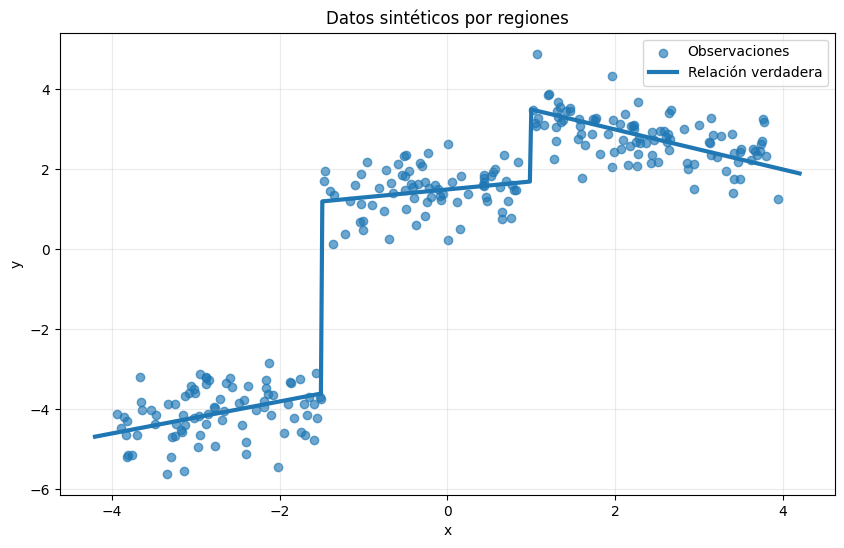

In [3]:
x_grid = np.linspace(-4.2, 4.2, 500)

true_grid = np.select(
    [
        x_grid < -1.5,
        (x_grid >= -1.5) & (x_grid < 1.0),
        x_grid >= 1.0,
    ],
    [
        -3.0 + 0.4 * x_grid,
        1.5 + 0.2 * x_grid,
        4.0 - 0.5 * x_grid,
    ],
)

plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], y, alpha=0.65, label="Observaciones")
plt.plot(
    x_grid,
    true_grid,
    linewidth=3,
    label="Relación verdadera",
)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Datos sintéticos por regiones")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


## 3. Split de entrenamiento y prueba

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
)

print(f"Train: {len(X_train)}")
print(f"Test: {len(X_test)}")


Train: 182
Test: 78


## 4. Primer árbol de regresión

Un árbol de regresión busca divisiones que reduzcan la variabilidad dentro de los nodos resultantes.

En cada hoja, la predicción suele ser el promedio de los valores objetivo de las observaciones que llegaron a esa región.

In [5]:
tree_model = DecisionTreeRegressor(
    max_depth=3,
    min_samples_leaf=8,
    random_state=RANDOM_STATE,
)

tree_model.fit(X_train, y_train)

train_predictions = tree_model.predict(X_train)
test_predictions = tree_model.predict(X_test)

first_metrics = pd.DataFrame({
    "Métrica": ["MAE", "RMSE", "R²"],
    "Train": [
        mean_absolute_error(y_train, train_predictions),
        mean_squared_error(y_train, train_predictions) ** 0.5,
        r2_score(y_train, train_predictions),
    ],
    "Test": [
        mean_absolute_error(y_test, test_predictions),
        mean_squared_error(y_test, test_predictions) ** 0.5,
        r2_score(y_test, test_predictions),
    ],
})

first_metrics


,Métrica,Train,Test
0,MAE,0.3910,0.4938
1,RMSE,0.5044,0.6227
2,R²,0.9736,0.9557


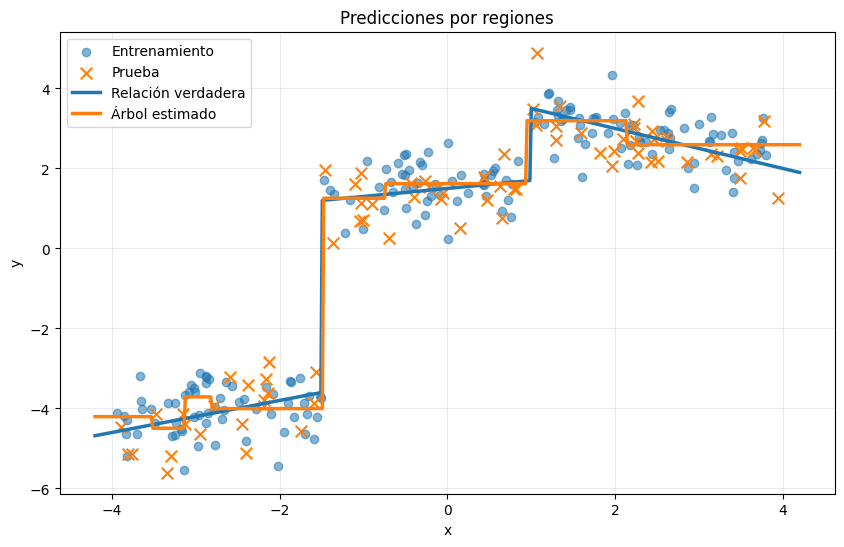

In [6]:
grid_predictions = tree_model.predict(
    x_grid.reshape(-1, 1)
)

plt.figure(figsize=(10, 6))
plt.scatter(
    X_train[:, 0],
    y_train,
    alpha=0.55,
    label="Entrenamiento",
)
plt.scatter(
    X_test[:, 0],
    y_test,
    marker="x",
    s=70,
    label="Prueba",
)
plt.plot(
    x_grid,
    true_grid,
    linewidth=2.5,
    label="Relación verdadera",
)
plt.plot(
    x_grid,
    grid_predictions,
    linewidth=2.5,
    label="Árbol estimado",
)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Predicciones por regiones")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


Las predicciones de un árbol son constantes dentro de cada hoja. Por eso la función estimada tiene forma escalonada.

## 5. Visualización de la estructura del árbol

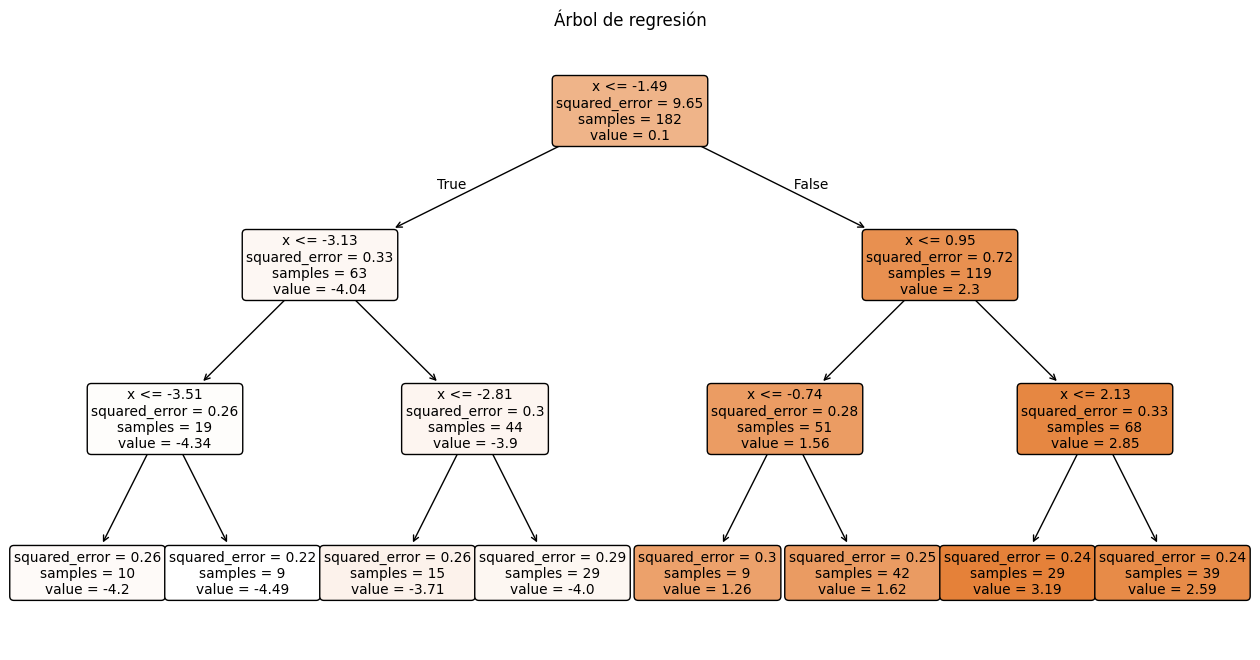

In [7]:
plt.figure(figsize=(16, 8))

plot_tree(
    tree_model,
    feature_names=["x"],
    filled=True,
    rounded=True,
    impurity=True,
    proportion=False,
    precision=2,
)

plt.title("Árbol de regresión")
plt.show()


Cada nodo muestra información como:

- regla de división;
- error cuadrático dentro del nodo;
- número de observaciones;
- valor promedio utilizado como predicción.

Las hojas son los nodos terminales.

In [8]:
tree_rules = export_text(
    tree_model,
    feature_names=["x"],
)

print(tree_rules)


|--- x <= -1.49
|   |--- x <= -3.13
|   |   |--- x <= -3.51
|   |   |   |--- value: [-4.20]
|   |   |--- x >  -3.51
|   |   |   |--- value: [-4.49]
|   |--- x >  -3.13
|   |   |--- x <= -2.81
|   |   |   |--- value: [-3.71]
|   |   |--- x >  -2.81
|   |   |   |--- value: [-4.00]
|--- x >  -1.49
|   |--- x <= 0.95
|   |   |--- x <= -0.74
|   |   |   |--- value: [1.26]
|   |   |--- x >  -0.74
|   |   |   |--- value: [1.62]
|   |--- x >  0.95
|   |   |--- x <= 2.13
|   |   |   |--- value: [3.19]
|   |   |--- x >  2.13
|   |   |   |--- value: [2.59]



## 6. Recorrido de una observación

Podemos identificar la hoja y el camino seguido por una nueva observación.

In [9]:
new_observations = np.array([
    [-3.0],
    [0.0],
    [2.5],
])

new_predictions = tree_model.predict(
    new_observations
)

leaf_ids = tree_model.apply(
    new_observations
)

prediction_table = pd.DataFrame({
    "x": new_observations[:, 0],
    "Hoja": leaf_ids,
    "Predicción": new_predictions,
})

prediction_table


,x,Hoja,Predicción
0,-3.0000,6,-3.7105
1,0.0000,11,1.6207
2,2.5000,14,2.5935


## 7. Efecto de la profundidad

La profundidad controla cuántas divisiones puede realizar el árbol.

- árbol poco profundo: alto sesgo;
- árbol muy profundo: alta varianza.

In [10]:
depths = [1, 2, 3, 5, 8, None]
depth_results = []

for depth in depths:
    model = DecisionTreeRegressor(
        max_depth=depth,
        random_state=RANDOM_STATE,
    )
    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    depth_results.append({
        "max_depth": str(depth),
        "Profundidad real": model.get_depth(),
        "Número de hojas": model.get_n_leaves(),
        "RMSE train": mean_squared_error(
            y_train,
            train_pred,
        ) ** 0.5,
        "RMSE test": mean_squared_error(
            y_test,
            test_pred,
        ) ** 0.5,
        "R² test": r2_score(y_test, test_pred),
    })

depth_results_df = pd.DataFrame(
    depth_results
)

depth_results_df


,max_depth,Profundidad real,Número de hojas,RMSE train,RMSE test,R² test
0,1,1,2,0.7624,0.8949,0.9084
1,2,2,4,0.5473,0.6389,0.9533
2,3,3,8,0.4960,0.6282,0.9549
3,5,5,28,0.4193,0.6470,0.9521
4,8,8,114,0.2428,0.7492,0.9358
5,None,20,182,0.0000,0.7883,0.9289


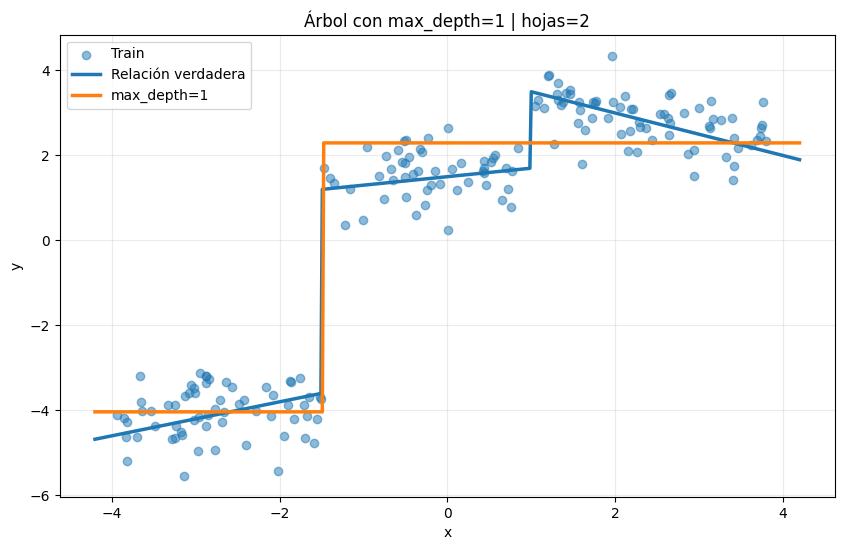

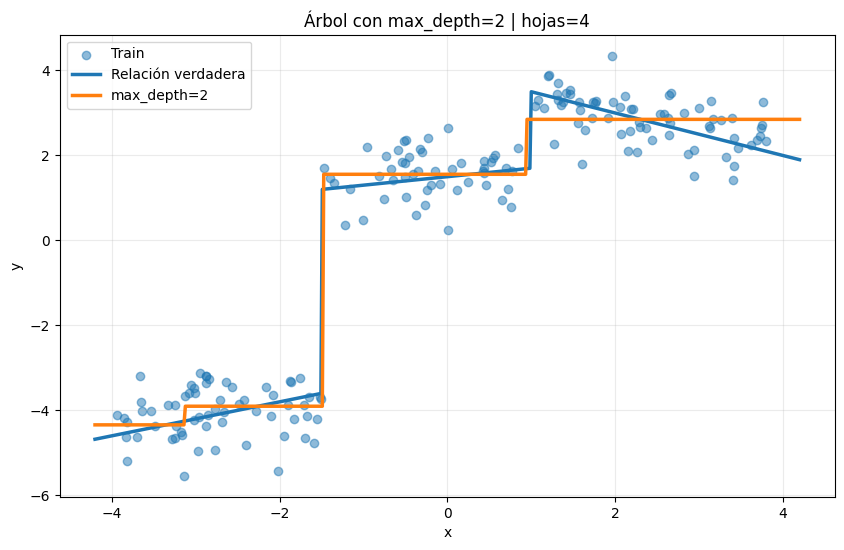

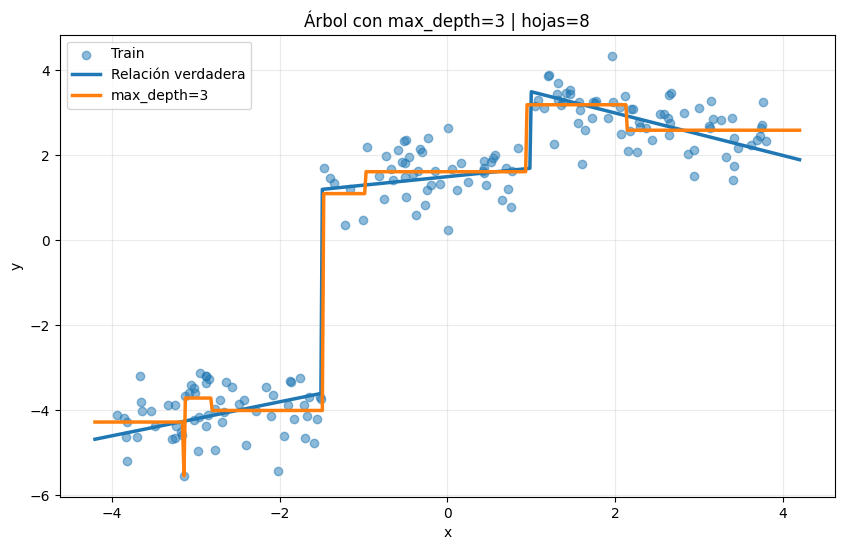

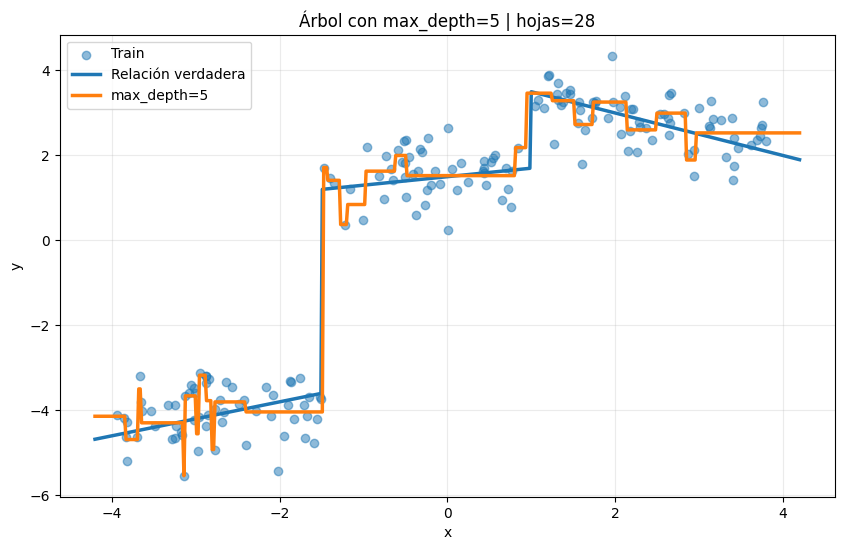

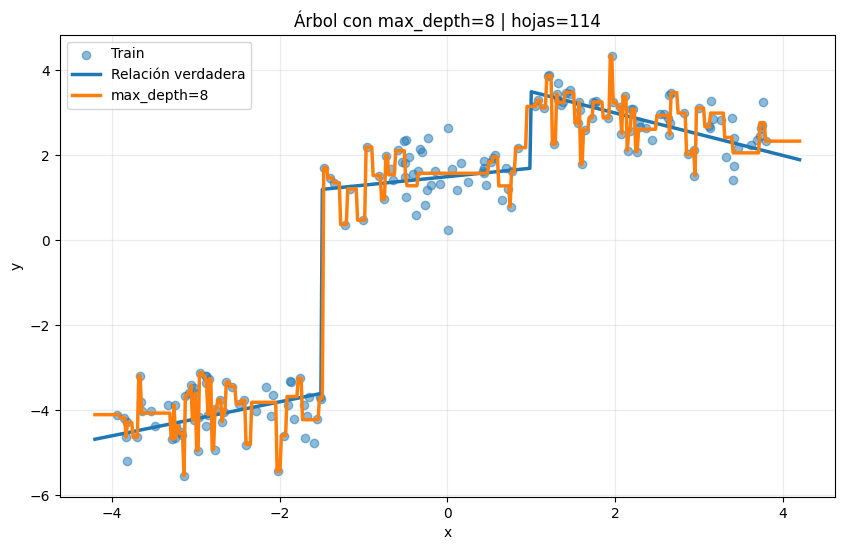

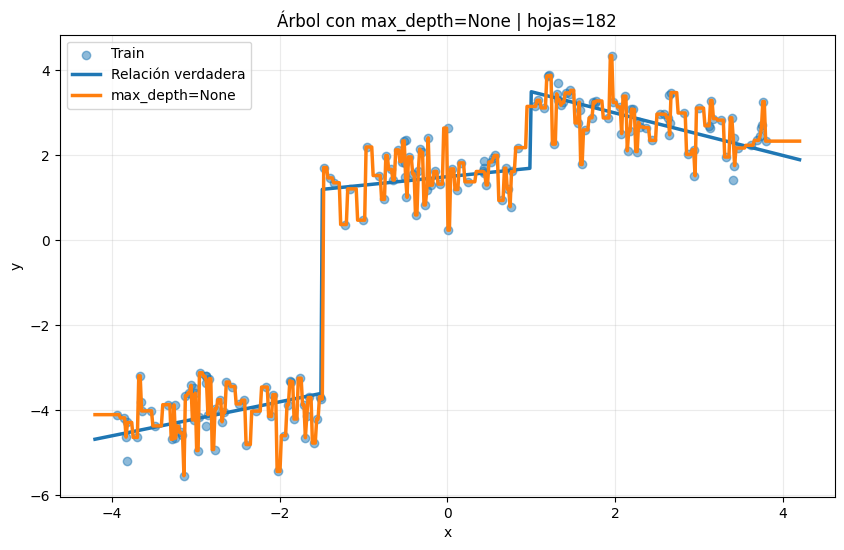

In [11]:
for depth in depths:
    model = DecisionTreeRegressor(
        max_depth=depth,
        random_state=RANDOM_STATE,
    )
    model.fit(X_train, y_train)

    plt.figure(figsize=(10, 6))
    plt.scatter(
        X_train[:, 0],
        y_train,
        alpha=0.5,
        label="Train",
    )
    plt.plot(
        x_grid,
        true_grid,
        linewidth=2.5,
        label="Relación verdadera",
    )
    plt.plot(
        x_grid,
        model.predict(x_grid.reshape(-1, 1)),
        linewidth=2.5,
        label=f"max_depth={depth}",
    )
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(
        f"Árbol con max_depth={depth} | "
        f"hojas={model.get_n_leaves()}"
    )
    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()


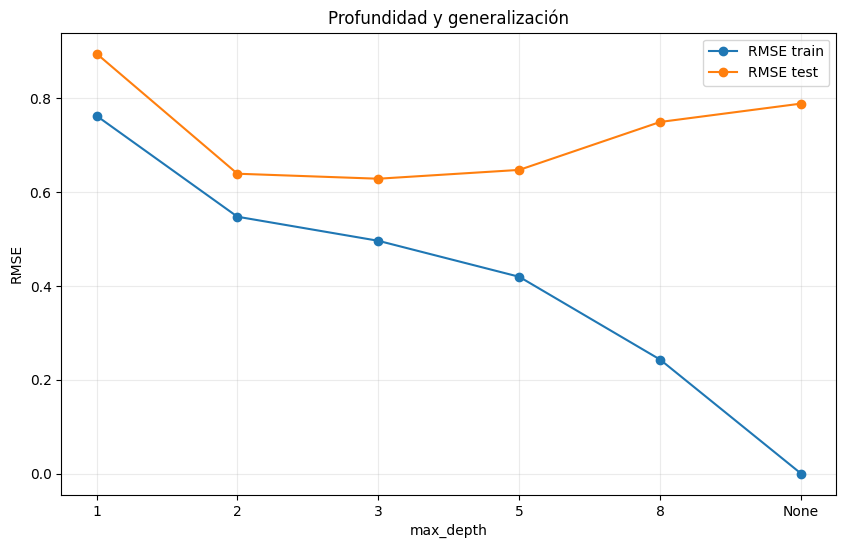

In [12]:
plt.figure(figsize=(10, 6))

positions = np.arange(len(depth_results_df))

plt.plot(
    positions,
    depth_results_df["RMSE train"],
    marker="o",
    label="RMSE train",
)

plt.plot(
    positions,
    depth_results_df["RMSE test"],
    marker="o",
    label="RMSE test",
)

plt.xticks(
    positions,
    depth_results_df["max_depth"],
)
plt.xlabel("max_depth")
plt.ylabel("RMSE")
plt.title("Profundidad y generalización")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


Un árbol sin restricciones puede dividir hasta memorizar observaciones individuales.

El error de entrenamiento disminuye, pero el error de prueba puede aumentar.

## 8. Control de complejidad

Los hiperparámetros más importantes incluyen:

- `max_depth`;
- `min_samples_split`;
- `min_samples_leaf`;
- `max_leaf_nodes`;
- `ccp_alpha`.

`min_samples_leaf` obliga a que cada hoja contenga un número mínimo de observaciones.

In [13]:
leaf_sizes = [1, 3, 8, 15, 30]
leaf_results = []

for leaf_size in leaf_sizes:
    model = DecisionTreeRegressor(
        max_depth=None,
        min_samples_leaf=leaf_size,
        random_state=RANDOM_STATE,
    )
    model.fit(X_train, y_train)

    leaf_results.append({
        "min_samples_leaf": leaf_size,
        "Profundidad": model.get_depth(),
        "Hojas": model.get_n_leaves(),
        "RMSE train": mean_squared_error(
            y_train,
            model.predict(X_train),
        ) ** 0.5,
        "RMSE test": mean_squared_error(
            y_test,
            model.predict(X_test),
        ) ** 0.5,
    })

leaf_results_df = pd.DataFrame(
    leaf_results
)

leaf_results_df


,min_samples_leaf,Profundidad,Hojas,RMSE train,RMSE test
0,1,20,182,0.0000,0.7883
1,3,10,51,0.3788,0.6907
2,8,7,18,0.4802,0.6269
3,15,4,9,0.5046,0.6159
4,30,3,5,0.5318,0.6304


Aumentar `min_samples_leaf` suaviza el modelo y reduce particiones basadas en muy pocas observaciones.

## 9. Árboles con varias variables

Generaremos un segundo dataset para analizar:

- selección automática de variables;
- interacciones;
- importancia de variables.

In [14]:
n_multi = 700

x1 = rng.normal(size=n_multi)
x2 = rng.normal(size=n_multi)
x3 = rng.normal(size=n_multi)
x4 = rng.normal(size=n_multi)
x5 = rng.normal(size=n_multi)

X_multi = pd.DataFrame({
    "x1": x1,
    "x2": x2,
    "x3": x3,
    "x4": x4,
    "x5": x5,
})

y_multi = (
    np.where(x1 > 0, 6, -4)
    + np.where(x2 > 0.8, 5, 0)
    + 4 * x3 * (x1 > 0)
    + rng.normal(0, 1.5, n_multi)
)

X_multi_train, X_multi_test, y_multi_train, y_multi_test = (
    train_test_split(
        X_multi,
        y_multi,
        test_size=0.25,
        random_state=RANDOM_STATE,
    )
)

multi_tree = DecisionTreeRegressor(
    max_depth=5,
    min_samples_leaf=10,
    random_state=RANDOM_STATE,
)

multi_tree.fit(
    X_multi_train,
    y_multi_train,
)

multi_predictions = multi_tree.predict(
    X_multi_test
)

print(
    "RMSE test:",
    mean_squared_error(
        y_multi_test,
        multi_predictions,
    ) ** 0.5,
)
print(
    "R² test:",
    r2_score(
        y_multi_test,
        multi_predictions,
    ),
)


RMSE test: 2.0180515108907127
R² test: 0.8881906825115448


## 10. Importancia de variables

In [15]:
importance_table = pd.DataFrame({
    "Variable": X_multi.columns,
    "Importancia": multi_tree.feature_importances_,
}).sort_values(
    "Importancia",
    ascending=False,
)

importance_table


,Variable,Importancia
0,x1,0.6789
2,x3,0.2354
1,x2,0.0829
3,x4,0.0020
4,x5,0.0007


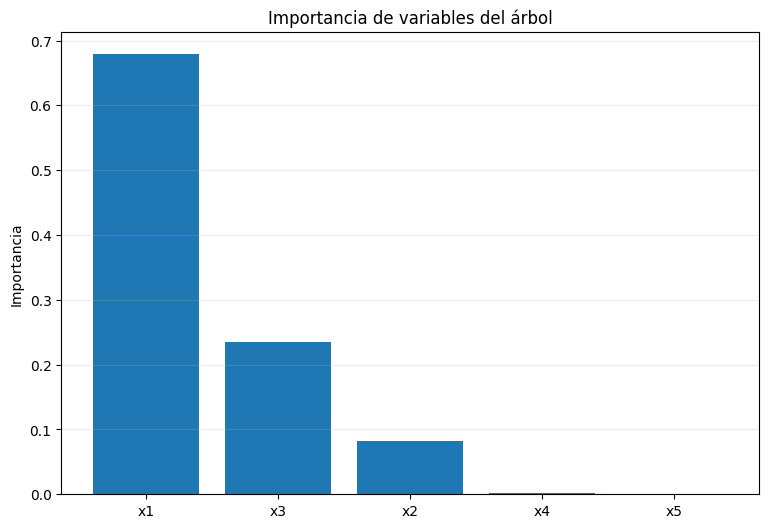

In [16]:
plt.figure(figsize=(9, 6))
plt.bar(
    importance_table["Variable"],
    importance_table["Importancia"],
)
plt.ylabel("Importancia")
plt.title("Importancia de variables del árbol")
plt.grid(axis="y", alpha=0.25)
plt.show()


La importancia basada en reducción de impureza indica cuánto contribuyó cada variable a las divisiones del árbol.

Precauciones:

- no implica causalidad;
- puede favorecer variables con muchos puntos de corte;
- puede repartirse entre variables correlacionadas;
- debe complementarse con otras herramientas de interpretación.

## 11. Los árboles no requieren escalamiento

Las reglas comparan una variable con un umbral. Multiplicar una variable por una constante cambia el valor del umbral, pero no altera el orden de las observaciones.

In [17]:
X_scaled_example = X_multi.copy()
X_scaled_example["x1"] = (
    X_scaled_example["x1"] * 100_000
)

X_scaled_train, X_scaled_test, y_scaled_train, y_scaled_test = (
    train_test_split(
        X_scaled_example,
        y_multi,
        test_size=0.25,
        random_state=RANDOM_STATE,
    )
)

scaled_tree = DecisionTreeRegressor(
    max_depth=5,
    min_samples_leaf=10,
    random_state=RANDOM_STATE,
)

scaled_tree.fit(
    X_scaled_train,
    y_scaled_train,
)

scaled_predictions = scaled_tree.predict(
    X_scaled_test
)

pd.DataFrame({
    "Modelo": [
        "Escala original",
        "x1 multiplicada por 100,000",
    ],
    "RMSE test": [
        mean_squared_error(
            y_multi_test,
            multi_predictions,
        ) ** 0.5,
        mean_squared_error(
            y_scaled_test,
            scaled_predictions,
        ) ** 0.5,
    ],
})


,Modelo,RMSE test
0,Escala original,2.0181
1,"x1 multiplicada por 100,000",2.0181


## 12. Poda por costo-complejidad

La poda busca simplificar un árbol ya crecido.

`ccp_alpha` controla el costo asignado a la complejidad:

- valor pequeño: árbol más grande;
- valor grande: árbol más pequeño.

In [18]:
unpruned_tree = DecisionTreeRegressor(
    random_state=RANDOM_STATE,
)

pruning_path = unpruned_tree.cost_complexity_pruning_path(
    X_train,
    y_train,
)

ccp_alphas = pruning_path.ccp_alphas

print(f"Número de valores candidatos: {len(ccp_alphas)}")
ccp_alphas[:10]


Número de valores candidatos: 135


array([0.00000000e+00, 2.16788560e-08, 2.26479569e-08, 5.84244439e-08,
       2.65138426e-07, 4.48518583e-07, 7.31599961e-07, 1.34646604e-06,
       1.85123147e-06, 2.14510929e-06])

In [19]:
pruning_results = []

# Usamos una selección de valores para mantener el ejemplo compacto
alpha_indices = np.linspace(
    0,
    len(ccp_alphas) - 1,
    min(25, len(ccp_alphas)),
    dtype=int,
)

selected_alphas = np.unique(
    ccp_alphas[alpha_indices]
)

for alpha in selected_alphas:
    model = DecisionTreeRegressor(
        random_state=RANDOM_STATE,
        ccp_alpha=alpha,
    )
    model.fit(X_train, y_train)

    pruning_results.append({
        "ccp_alpha": alpha,
        "Profundidad": model.get_depth(),
        "Hojas": model.get_n_leaves(),
        "RMSE train": mean_squared_error(
            y_train,
            model.predict(X_train),
        ) ** 0.5,
        "RMSE test": mean_squared_error(
            y_test,
            model.predict(X_test),
        ) ** 0.5,
    })

pruning_results_df = pd.DataFrame(
    pruning_results
)

pruning_results_df.head()


,ccp_alpha,Profundidad,Hojas,RMSE train,RMSE test
0,0.0000,20,182,0.0000,0.7883
1,0.0000,20,177,0.0009,0.7882
2,0.0000,20,171,0.0038,0.7881
3,0.0000,20,166,0.0076,0.7878
4,0.0000,20,160,0.0122,0.7884


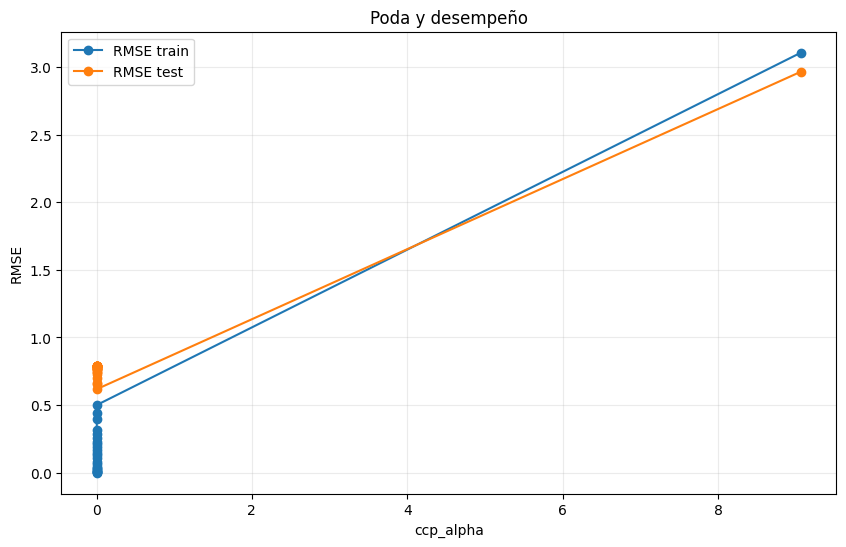

In [20]:
plt.figure(figsize=(10, 6))

plt.plot(
    pruning_results_df["ccp_alpha"],
    pruning_results_df["RMSE train"],
    marker="o",
    label="RMSE train",
)

plt.plot(
    pruning_results_df["ccp_alpha"],
    pruning_results_df["RMSE test"],
    marker="o",
    label="RMSE test",
)

plt.xlabel("ccp_alpha")
plt.ylabel("RMSE")
plt.title("Poda y desempeño")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


En un proyecto real, `ccp_alpha` debe seleccionarse mediante validación cruzada, no observando repetidamente el test.

## 13. Limitación: extrapolación

Los árboles predicen promedios de hojas. Fuera del rango observado, continúan usando el valor de una hoja extrema.

In [21]:
extrapolation_points = np.array([
    [-8.0],
    [-5.0],
    [5.0],
    [8.0],
])

extrapolation_predictions = tree_model.predict(
    extrapolation_points
)

pd.DataFrame({
    "x": extrapolation_points[:, 0],
    "Predicción del árbol": extrapolation_predictions,
})


,x,Predicción del árbol
0,-8.0000,-4.2044
1,-5.0000,-4.2044
2,5.0000,2.5935
3,8.0000,2.5935


Esto los hace poco apropiados cuando se necesita extrapolar una tendencia continua.

## 14. Errores frecuentes

1. Entrenar un árbol sin restricciones y evaluar únicamente en train.
2. Suponer que mayor profundidad siempre es mejor.
3. Elegir hiperparámetros con el test.
4. Interpretar importancia como causalidad.
5. Esperar extrapolación fuera del rango.
6. Pensar que los árboles siempre son estables.
7. Ignorar que pequeñas variaciones de datos pueden cambiar divisiones.
8. Usar árboles muy pequeños y concluir que el algoritmo no funciona.
9. Escalar por costumbre sin reconocer que no es necesario.
10. No revisar el tamaño de las hojas.

## 15. Experimentos sugeridos

### Experimento 1

Compara:

```python
max_depth = 1, 2, 3, 5, 10, None
```

### Experimento 2

Varía `min_samples_leaf`.

### Experimento 3

Cambia el nivel de ruido de los datos.

### Experimento 4

Agrega outliers y observa cómo cambian las divisiones.

### Experimento 5

Compara un árbol con regresión lineal sobre la relación por tramos.

### Experimento 6

Genera una relación suave y analiza la forma escalonada del árbol.

### Experimento 7

Repite el entrenamiento con diferentes muestras y compara la estructura.

### Experimento 8

Usa validación cruzada para seleccionar `ccp_alpha`.

## 16. Resumen

En este notebook:

- ajustamos un árbol de regresión;
- visualizamos sus reglas y hojas;
- observamos predicciones constantes por región;
- estudiamos el efecto de la profundidad;
- controlamos complejidad con varios hiperparámetros;
- analizamos importancia de variables;
- comprobamos que no requiere escalamiento;
- aplicamos poda por costo-complejidad;
- discutimos su incapacidad para extrapolar.

Los árboles son flexibles, interpretables cuando son pequeños y capaces de representar no linealidades e interacciones. Sin control de complejidad, pueden sobreajustar con facilidad.